In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
U = 165        # В -- считаем постоянным
I_porog = 14.2 # А

## Измерения


### мощность лазера от мощности накачки (Card, Mirror, ток) в режиме current CV

`Card` ОЧЕНЬ сильно прыгает

Card - мВт

Mirror - мВт

I - А

In [8]:
data1 = pd.read_csv("data1.csv")
data1.head()

,Power,Mirror,Card,I
0,50.0,1,1,12.7
1,53.0,2,2,13.5
2,55.0,2,2,14.0
3,55.5,8,9,14.1
4,55.7,16,17,14.2


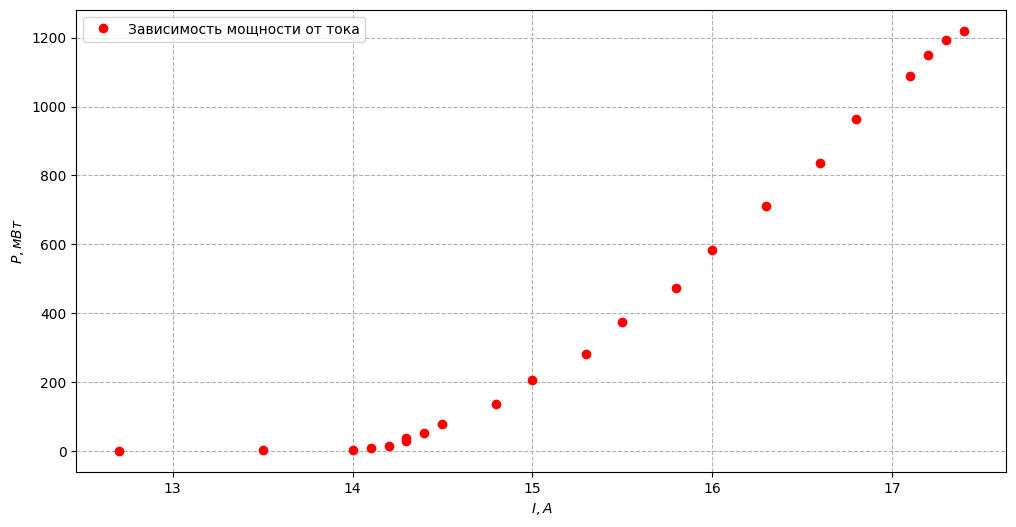

In [15]:
plt.figure(figsize=(12, 6))

plt.grid(True, linestyle='--')
plt.xlabel(r"$I, А$")
plt.ylabel(r"$P, мВт$")

plt.errorbar(x=data1["I"], y=data1["Mirror"], fmt="or", label="Зависимость мощности от тока")

plt.legend()
plt.show()

### То же самое с осциллографом в режиме добротности

In [28]:
data2 = pd.read_csv("data2.csv")
data2.head()

,Power,Mirror,Card,I
0,51.8,2,1,13.2
1,53.0,2,2,13.5
2,55.0,5,3,14.0
3,56.0,58,59,14.3
4,56.9,105,110,14.5


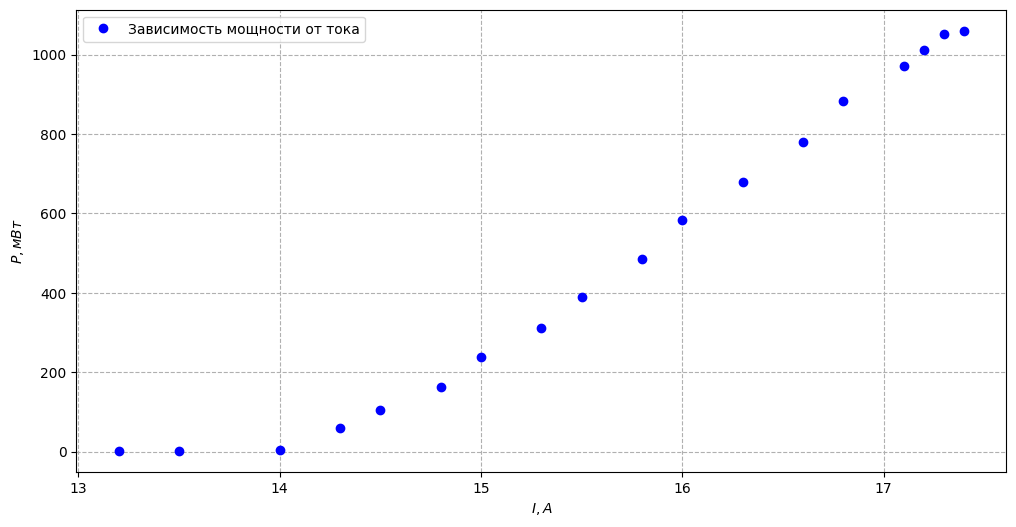

In [29]:
plt.figure(figsize=(12, 6))

plt.grid(True, linestyle='--')
plt.xlabel(r"$I, А$")
plt.ylabel(r"$P, мВт$")

plt.errorbar(x=data2["I"], y=data2["Mirror"], fmt="ob", label="Зависимость мощности от тока")

plt.legend()
plt.show()

### Ширина импульса


delta_T - нс

In [38]:
data_impulse = pd.read_csv("data_width.csv")
data_impulse.head()

,Power,Mirror,Card,I,delta_T
0,57.1,128,130,14.5,780
1,60.0,323,320,15.3,650
2,62.0,500,500,15.8,574
3,64.0,700,701,16.3,553
4,66.0,900,905,16.8,522


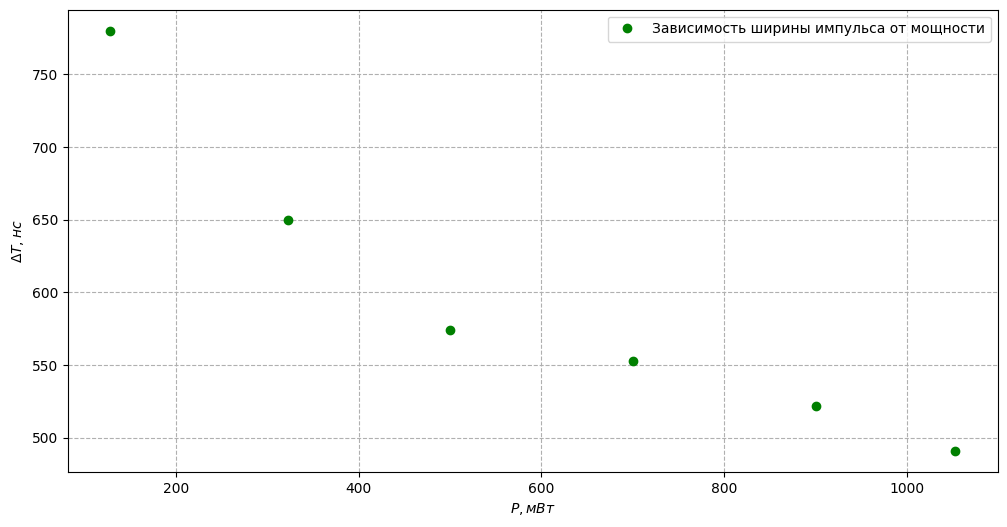

In [40]:
plt.figure(figsize=(12, 6))

plt.grid(True, linestyle='--')
plt.xlabel(r"$P, мВт$")
plt.ylabel(r"$\Delta T, нс$")

plt.errorbar(x=data_impulse["Mirror"], y=data_impulse["delta_T"], fmt="og", label="Зависимость ширины импульса от мощности")

plt.legend()
plt.show()

In [2]:
def N_1(t, N_0, omega, tau, C):
    N_11 = N_0 * (omega + 1/tau) / (2*omega + 1/tau)
    N_10 = C*np.exp(
        -(2*omega + 1/tau) * t
    )
    return N_11 + N_10

In [3]:
def N_2(t, N_0, omega, tau, C):
    return N_0 - N_1(t, N_0, omega, tau, C)

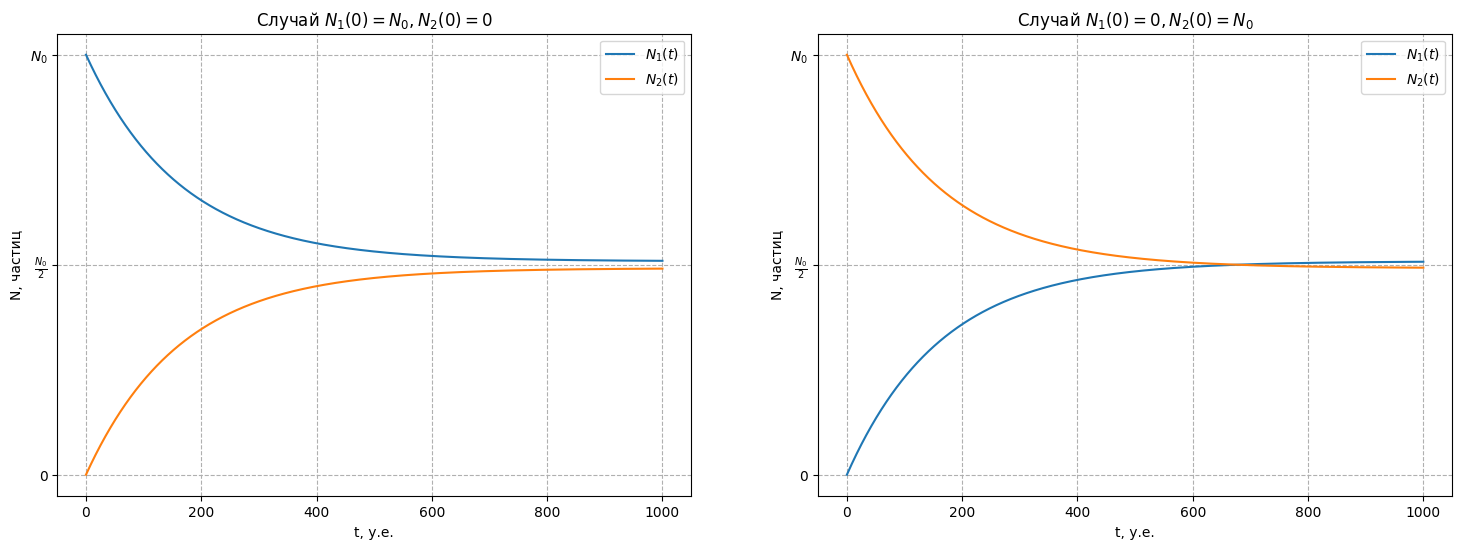

In [37]:
N_0 = 100
omega = 3e-3
tau = 1e4

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plt.grid(True, linestyle='--')
plt.title(r"Случай $N_1(0) = N_0, N_2(0) = 0$")

t_grid = np.linspace(0, 1000, 10000)

N_1_0 = N_0
N_2_0 = 0
C = N_0 * omega / (2*omega + 1/tau)
N_1_grid = N_1(t_grid, N_0, omega, tau, C)
N_2_grid = N_2(t_grid, N_0, omega, tau, C)

plt.plot(t_grid, N_1_grid, label=r"$N_1(t)$")
plt.plot(t_grid, N_2_grid, label=r"$N_2(t)$")

plt.xlabel(r"t, у.е.")
plt.ylabel(r"N, частиц")


plt.xlabel(r"t, у.е.")
plt.ylabel(r"N, частиц")

plt.yticks(ticks=[0, N_0/2, N_0], labels=["0", r"$\frac{N_0}{2}$", r"$N_0$"])

plt.legend()

plt.subplot(1, 2, 2)
plt.grid(True, linestyle='--')
plt.title(r"Случай $N_1(0) = 0, N_2(0) = N_0$")

t_grid = np.linspace(0, 1000, 10000)

N_1_0 = 0
N_2_0 = N_0
C = - N_0 * (omega + 1/tau) / (2*omega + 1/tau)
N_1_grid = N_1(t_grid, N_0, omega, tau, C)
N_2_grid = N_2(t_grid, N_0, omega, tau, C)

plt.plot(t_grid, N_1_grid, label=r"$N_1(t)$")
plt.plot(t_grid, N_2_grid, label=r"$N_2(t)$")

plt.xlabel(r"t, у.е.")
plt.ylabel(r"N, частиц")

plt.yticks(ticks=[0, N_0/2, N_0], labels=["0", r"$\frac{N_0}{2}$", r"$N_0$"])


plt.legend()
plt.savefig("zaselennost.pdf")
plt.show()